/Users/ivanaphanasyev/l/vins-rnd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-09-24 at 20:42:38 | Loading dataset from disk at /Users/ivanaphanasyev/l/vins-rnd/datasets/euroc_v_01_easy/cache/full
2025-09-24 at 20:42:38 | Dataset not found on disk, creating from scratch...
2025-09-24 at 20:42:38 | Creating panda dataframe from csv files...
2025-09-24 at 20:42:38 | Loading left camera dataframe...
2025-09-24 at 20:42:38 | Loading right camera dataframe...
2025-09-24 at 20:42:38 | Loading imu dataframe...
2025-09-24 at 20:42:38 | Loading ground truth dataframe...
2025-09-24 at 20:42:38 | Creating dataset from dataframe...


Saving the dataset (1/1 shards): 100%|██████████| 35721/35721 [00:03<00:00, 11151.11 examples/s]


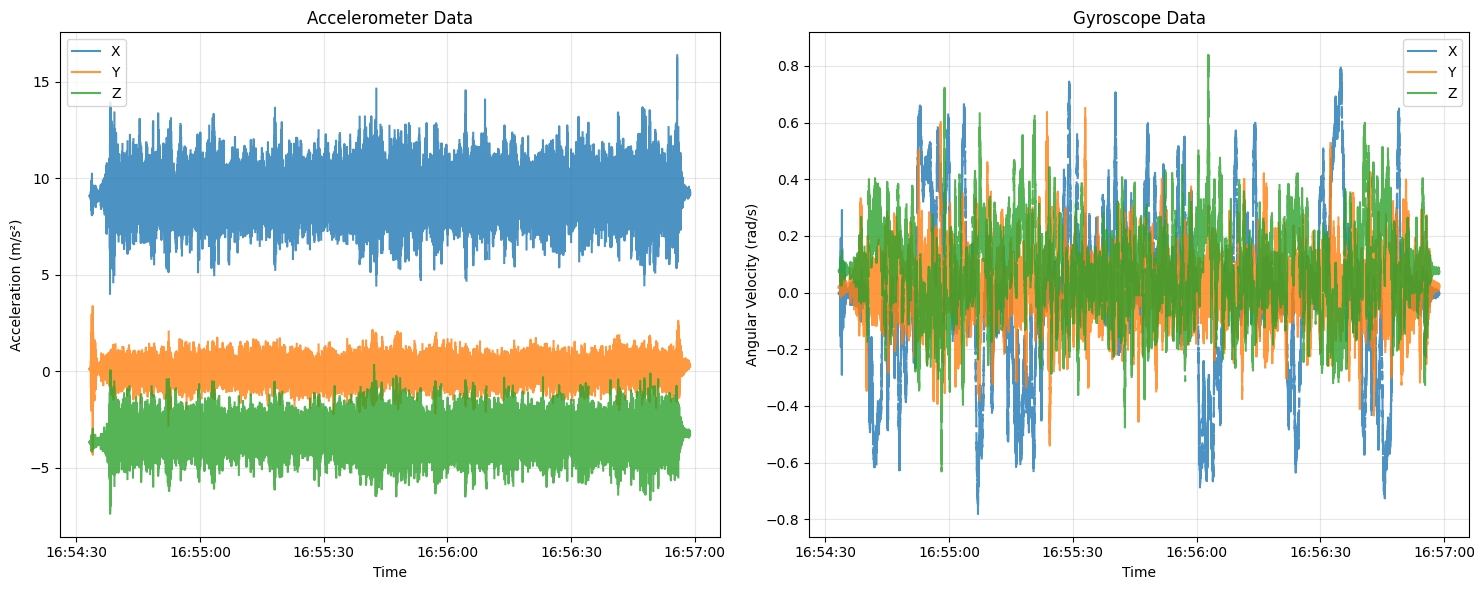

In [1]:
import datetime

import matplotlib.pyplot as plt
import numpy as np

from dataset.euroc import EurocDataset

euroc = EurocDataset.mh_01_easy()


dictionary = euroc.ds.to_dict()
accelerometer_data = dictionary["acc"]
gyroscope_data = dictionary["gyro"]
timestamps = dictionary["timestamp"]

# Convert JAX arrays to regular Python values
timestamps_float = np.array(timestamps)
timestamps_float = [ts / 1e9 for ts in timestamps_float]
timestamps_dt = [
    datetime.datetime.fromtimestamp(ts, tz=datetime.timezone.utc) for ts in timestamps_float
]
# Extract individual components (convert JAX arrays to regular values)
acc_x = [acc[0] for acc in accelerometer_data]
acc_y = [acc[1] for acc in accelerometer_data]
acc_z = [acc[2] for acc in accelerometer_data]

gyro_x = [gyro[0] for gyro in gyroscope_data]
gyro_y = [gyro[1] for gyro in gyroscope_data]
gyro_z = [gyro[2] for gyro in gyroscope_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot accelerometer data
ax1.set_title("Accelerometer Data")
ax1.plot(timestamps_dt, acc_x, label="X", alpha=0.8)
ax1.plot(timestamps_dt, acc_y, label="Y", alpha=0.8)
ax1.plot(timestamps_dt, acc_z, label="Z", alpha=0.8)
ax1.set_ylabel("Acceleration (m/s²)")
ax1.set_xlabel("Time")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot gyroscope data
ax2.set_title("Gyroscope Data")
ax2.plot(timestamps_dt, gyro_x, label="X", alpha=0.8)
ax2.plot(timestamps_dt, gyro_y, label="Y", alpha=0.8)
ax2.plot(timestamps_dt, gyro_z, label="Z", alpha=0.8)
ax2.set_ylabel("Angular Velocity (rad/s)")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

2025-09-24 at 20:42:44 | Loading dataset from disk at /Users/ivanaphanasyev/l/vins-rnd/datasets/euroc_v_01_easy/cache/full


Filter: 100%|██████████| 35721/35721 [00:00<00:00, 86688.43 examples/s]


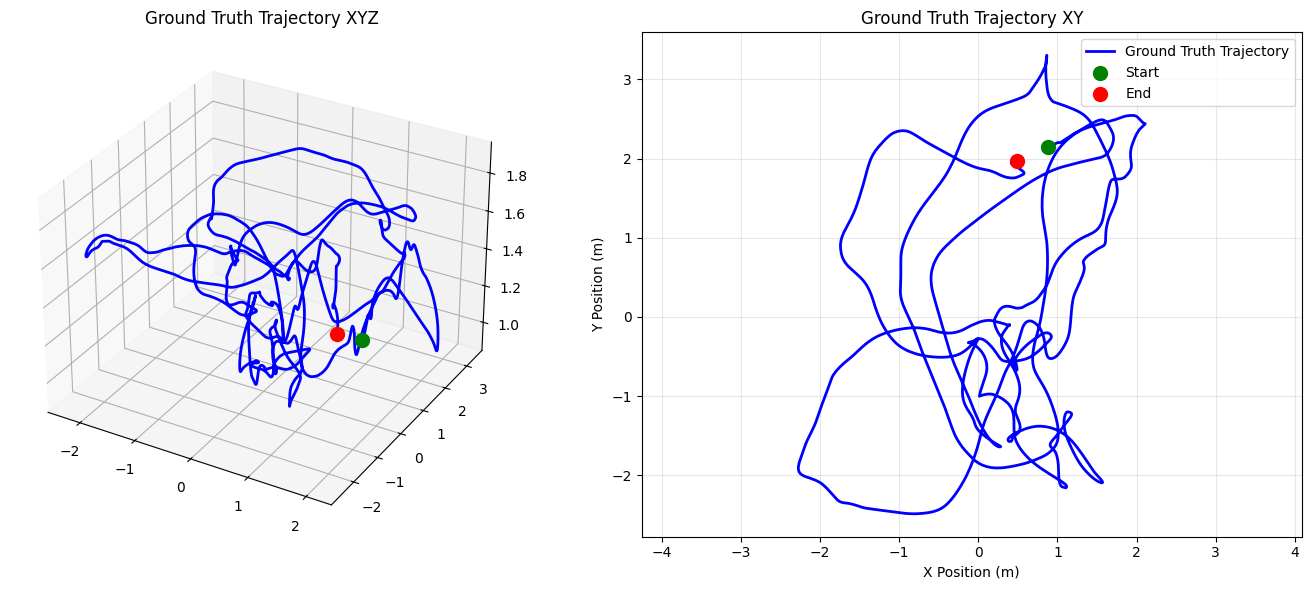

In [2]:
import matplotlib.pyplot as plt

from dataset.euroc import EurocDataset

ground_truth = EurocDataset.mh_01_easy().ground_truth()
dictionary = ground_truth.to_dict()
gt_pos = dictionary["gt_position"]

# Extract x, y coordinates from ground truth positions
gt_x = [float(pos[0]) for pos in gt_pos]
gt_y = [float(pos[1]) for pos in gt_pos]
gt_z = [float(pos[2]) for pos in gt_pos]


fig = plt.figure(figsize=(14, 6))

ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.set_title("Ground Truth Trajectory XYZ")
ax3d.plot(gt_x, gt_y, gt_z, "b-", linewidth=2, label="Ground Truth Trajectory")
ax3d.scatter(gt_x[0], gt_y[0], gt_z[0], color="green", s=100, label="Start", zorder=5)
ax3d.scatter(gt_x[-1], gt_y[-1], gt_z[-1], color="red", s=100, label="End", zorder=5)

ax2d = fig.add_subplot(1, 2, 2)
# Plot ground truth trajectory
ax2d.plot(gt_x, gt_y, "b-", linewidth=2, label="Ground Truth Trajectory")
ax2d.scatter(gt_x[0], gt_y[0], color="green", s=100, label="Start", zorder=5)
ax2d.scatter(gt_x[-1], gt_y[-1], color="red", s=100, label="End", zorder=5)

ax2d.set_xlabel("X Position (m)")
ax2d.set_ylabel("Y Position (m)")
ax2d.set_title("Ground Truth Trajectory XY")
ax2d.legend()
ax2d.grid(alpha=0.3)
ax2d.axis("equal")

plt.tight_layout()
plt.show()

2025-09-24 at 20:42:45 | Loading dataset from disk at /Users/ivanaphanasyev/l/vins-rnd/datasets/euroc_v_01_easy/cache/full


Filter: 100%|██████████| 35721/35721 [00:15<00:00, 2302.09 examples/s]


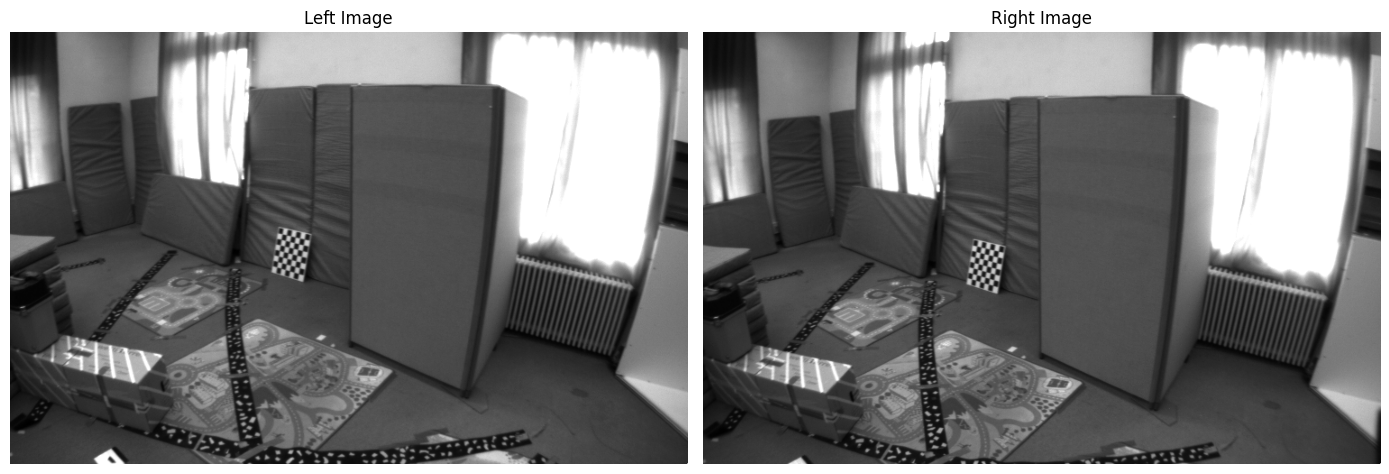

In [3]:
import matplotlib.pyplot as plt

from dataset.euroc import EurocDataset

stereo = EurocDataset.mh_01_easy().stereo()

shuffled = stereo.shuffle(seed=2025)
random_sample = shuffled["stereo"][0]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(random_sample[0], cmap="gray")
ax1.set_title("Left Image")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(random_sample[1], cmap="gray")
ax2.set_title("Right Image")
# remove x,y ticks axis
ax2.axis("off")
ax1.axis("off")

plt.tight_layout()
plt.show()